<a href="https://colab.research.google.com/github/Asaf-Greenfield-2/ML4P_Asaf_3/blob/main/ML4P_Final_Project_Code_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
import numpy as np, os
from astropy.io import fits
drive.mount('/content/drive')

# find wherever "Copy of labels.fits" actually lives under MyDrive
base = None
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if any('labels' in f and f.endswith('.fits') for f in files):
        base = root
        break
print("found data in:", base)

def find(keyword):
    hits = [f for f in os.listdir(base) if keyword in f]
    return os.path.join(base, hits[0])

hdul = fits.open(find('labels'))
labels = hdul[1].data
print("loaded, n rows:", len(labels))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
found data in: /content/drive/MyDrive/ML4P_Asaf/PS1_ML4P_Asaf's
loaded, n rows: 733901


In [3]:
# same red-giant-branch cut as PS1 so the sample is clean
RGB = (
    (labels['TEFF'] > 3500.) & (labels['TEFF'] < 5400.) &
    (labels['LOGG'] > 0.0)   & (labels['LOGG'] < 3.0)   &
    (labels['H']    < 10.5)
)
rgb = labels[RGB]

# physical parameters we'll try to relate
teff = np.asarray(rgb['TEFF'], dtype=np.float64)
logg = np.asarray(rgb['LOGG'], dtype=np.float64)
m_h  = np.asarray(rgb['M_H'],  dtype=np.float64)

# drop sentinel/missing values (APOGEE uses -9999)
good = (teff > 0) & (logg > -100) & (m_h > -100)
teff, logg, m_h = teff[good], logg[good], m_h[good]
print("n stars:", len(teff))
print("TEFF range:", teff.min(), teff.max())
print("LOGG range:", logg.min(), logg.max())
print("M_H  range:", m_h.min(),  m_h.max())

# subsample so pysr runs fast (doesn't need all of them)
rng = np.random.default_rng(17)
idx = rng.choice(len(teff), size=2000, replace=False)
teff_s, logg_s, m_h_s = teff[idx], logg[idx], m_h[idx]

n stars: 145931
TEFF range: 3500.0263671875 5393.21044921875
LOGG range: 0.0006282106041908264 2.999983787536621
M_H  range: -2.4630000591278076 0.6011099815368652


In [6]:
!pip install pysr
from pysr import PySRRegressor

# normalize inputs - TEFF~4000 vs M_H~0 are wildly different scales
teff_n = (teff_s - teff_s.mean()) / teff_s.std()
mh_n   = (m_h_s  - m_h_s.mean())  / m_h_s.std()
X = np.column_stack([teff_n, mh_n])   # x0 = normalized TEFF, x1 = normalized M_H
y = logg_s

model = PySRRegressor(
    niterations=80,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=["square", "exp"],
    maxsize=15,
    verbosity=0, progress=False,
)
model.fit(X, y)
print(model)
print("\nTEFF: mean", teff_s.mean(), "std", teff_s.std())
print("M_H : mean", m_h_s.mean(),  "std", m_h_s.std())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 18.4 MB/s eta 0:00:00
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] WARNING: You have Julia 1.12.6 installed but 1.10.3 - 1.11 is required.
[juliapkg]   It is recommended that you upgrade Julia or install JuliaUp.
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.9 to /root/.julia/environments/pyjuliapkg/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[

RMSE of symbolic fit: 0.1831 dex
scatter in LOGG itself: 0.6854 dex


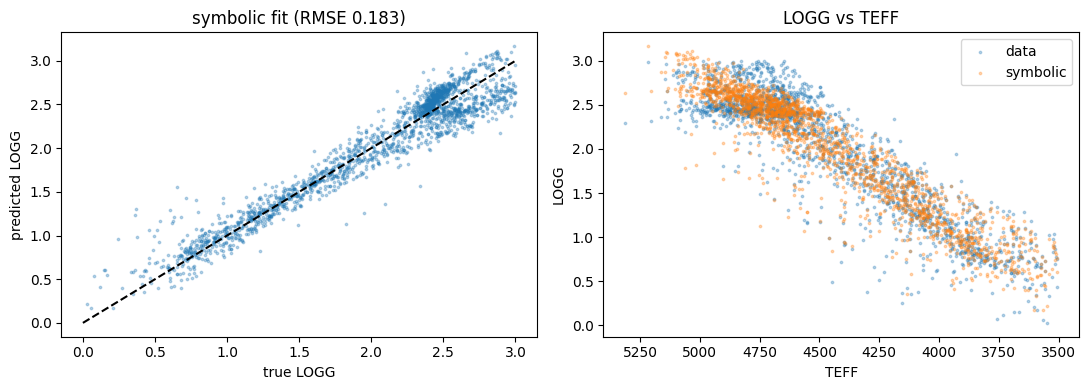

In [7]:
import matplotlib.pyplot as plt

pred = model.predict(X)
resid = y - pred
rmse = np.sqrt(np.mean(resid**2))
print("RMSE of symbolic fit:", round(rmse, 4), "dex")
print("scatter in LOGG itself:", round(y.std(), 4), "dex")   # baseline to beat

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(y, pred, s=3, alpha=0.3)
ax[0].plot([0,3],[0,3],'k--'); ax[0].set_xlabel("true LOGG"); ax[0].set_ylabel("predicted LOGG")
ax[0].set_title(f"symbolic fit (RMSE {rmse:.3f})")
ax[1].scatter(teff_s, y, s=3, alpha=0.3, label="data")
ax[1].scatter(teff_s, pred, s=3, alpha=0.3, label="symbolic")
ax[1].set_xlabel("TEFF"); ax[1].set_ylabel("LOGG"); ax[1].invert_xaxis(); ax[1].legend()
ax[1].set_title("LOGG vs TEFF")
plt.tight_layout(); plt.show()